In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import re

In [3]:
BASE = Path('/nlp/scr/salilg/showcase_property_tax/results/geo_pooling')

# helper functions

In [10]:
def format_model_name(model_name):
    if model_name == 'tabpfn':
        return 'TabPFN'
    elif model_name == 'xgboost':
        return 'XGBoost'
    elif model_name == 'tabpfn_global_finetuned':
        return 'TabPFN (finetuned globally)'
    elif model_name == 'tabpfn_finetuned':
        return 'TabPFN (finetuned per county)'
    else:
        return model_name

def format_epoch_name(ep):
    if ep == 'ep50':
        return '50 epoch steps'
    elif ep == 'ep100':
        return '100 epoch steps'
    else:
        return f'{ep} epoch steps'

def format_pooling_name(pooling):
    if pooling == 'nopooling':
        return 'No inference-time pooling'
    elif pooling == 'ratio80':
        return 'Inference-time pooling ratio 80%'
    else:
        return 'No pooling'

In [ ]:
def load_sweep_df(sweep_dir=BASE / 'v2_no_onehot/sweep'):
    """Load all sweep results into one DataFrame, parsing lora/lr/ep/seed/pooling from dir name."""
    pat = re.compile(r'(lora\d+)_(lr[\de-]+)_(ep\d+)_s(\d+)_(.*)')
    dfs = []
    for d in sorted(Path(sweep_dir).iterdir()):
        m = pat.match(d.name)
        if not m:
            continue
        lora, lr, ep, seed, pooling = m.groups()
        chunks = [pd.read_csv(d / f'chunk_{i}/results.csv')
                  for i in range(4) if (d / f'chunk_{i}/results.csv').exists()]
        if not chunks:
            continue
        df = pd.concat(chunks, ignore_index=True)
        df = df[df['status'] == 'success']
        df[['lora', 'lr', 'ep', 'seed', 'pooling']] = lora, lr, ep, seed, pooling
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def _parse_lora(s):   return int(re.search(r'\d+', s).group())
def _parse_lr(s):     return float(s.replace('lr', '').replace('e-', 'e-'))  # already valid float str




def plot_sweep_grid(
    df,
    metric='mape',
    train_size_col='own_train_size',
    bucket_size=40,
    n_se=2,
    ylim=None,
    model_filter='tabpfn_global_finetuned',
    df2=None
):
    """
    Grid of subplots: rows = LoRA rank, cols = LR.
    Lines on each subplot = (ep, pooling) combinations.
    SE is pooled across seeds and counties.
    """
    if model_filter:
        df = df[df['model'] == model_filter].copy()
    else:
        df = df.copy()

    df['_bucket'] = (df[train_size_col] // bucket_size) * bucket_size

    ## COMPARISON STATS: plotting 'zero shot' tabpfn and xgboost
    comp_stats = None
    if df2 is not None:
        df2 = df2.copy()
        df2['_bucket'] = (df2[train_size_col] // bucket_size) * bucket_size

        comp_stats = (
            df2[df2['model'].isin(['tabpfn', 'xgboost'])]
              .groupby(['_bucket', 'model', 'experiment'])[metric]
              .agg(['mean', 'std', 'count'])
              .reset_index()
              .sort_values('_bucket')
        )
        comp_stats['se'] = comp_stats['std'] / np.sqrt(comp_stats['count'])

    loras    = sorted(df['lora'].unique(),   key=_parse_lora)
    lrs      = sorted(df['lr'].unique(),     key=lambda s: float(s[2:]))
    eps      = sorted(df['ep'].unique(),     key=lambda s: int(s[2:]))
    poolings = sorted(df['pooling'].unique())

    line_groups = [(ep, pool) for ep in eps for pool in poolings]
    palette   = sns.color_palette("tab10", n_colors=len(line_groups))
    color_map = {g: palette[i] for i, g in enumerate(line_groups)}
    ls_map    = {'ep50': '--', 'ep100': '-'}

    nrows, ncols = len(loras), len(lrs)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3.5 * nrows),
                             sharex=True, sharey=True,
                             squeeze=False)

    for ri, lora in enumerate(loras):
        for ci, lr in enumerate(lrs):
            ax = axes[ri, ci]
            sub = df[(df['lora'] == lora) & (df['lr'] == lr)]

            for ep, pooling in line_groups:
                grp = sub[(sub['ep'] == ep) & (sub['pooling'] == pooling)]
                if grp.empty:
                    continue
                stats = (grp.groupby('_bucket')[metric]
                            .agg(['mean', 'std', 'count'])
                            .reset_index()
                            .sort_values('_bucket'))
                stats['se'] = stats['std'] / np.sqrt(stats['count'])

                ax.errorbar(
                    stats['_bucket'],
                    stats['mean'],
                    yerr=n_se * stats['se'],
                    label=f'TabPFN global finetuning with {format_epoch_name(ep)} ({format_pooling_name(pooling)})',
                    color=color_map[(ep, pooling)],
                    linestyle=ls_map.get(ep, '-'),
                    fmt='o', capsize=2, linewidth=1.5, markersize=3,
                )

            ## COMPARISON STATS: plotting 'zero shot' tabpfn and xgboost
            if comp_stats is not None:
                comp_styles = {
                    ('tabpfn',  'Pooling ratio 80%'): dict(color='black', linestyle='-',  fmt='o'),
                    ('xgboost', 'Pooling ratio 80%'): dict(color='black', linestyle='--', fmt='x'),
                    ('tabpfn',  'No pooling'):        dict(color='gray',  linestyle='-',  fmt='o'),
                    ('xgboost', 'No pooling'):        dict(color='gray',  linestyle='--', fmt='x'),
                }

                for (model, experiment), cdf in comp_stats.groupby(['model', 'experiment']):
                    style = comp_styles.get((model, experiment), dict(color='gray', linestyle=':', fmt='o'))
                    cdf = cdf.sort_values('_bucket')

                    ax.errorbar(
                        cdf['_bucket'],
                        cdf['mean'],
                        yerr=n_se * cdf['se'],
                        label=f'{format_model_name(model)} ({experiment})',
                        capsize=2,
                        linewidth=1.8,
                        markersize=3,
                        alpha=0.9,
                        **style,
                    )

            ax.set_title(f'{lora}  {lr}', fontsize=9)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            if ylim:
                ax.set_ylim(ylim)
            if ri == nrows - 1:
                ax.set_xlabel(f'{train_size_col}\n(bin={bucket_size})', fontsize=8)
            if ci == 0:
                ax.set_ylabel(metric.upper(), fontsize=8)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(line_groups),
               fontsize=9, title='(epochs, pooling)', bbox_to_anchor=(0.5, -0.02), handlelength=4)
    fig.suptitle(
        f'{metric.upper()} vs {train_size_col}  |  mean ± {n_se} SE\n'
        f'rows = LoRA rank, cols = LR, lines = (epochs × pooling)',
        fontsize=11
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.show()


In [16]:
def plot_sweep_grid_diff_from_baseline(
    df,
    baseline,   # ('sweep', ep, pooling) OR ('comparison', experiment, model)
    metric='mape',
    train_size_col='own_train_size',
    bucket_size=40,
    n_se=2,
    ylim=None,
    model_filter='tabpfn_global_finetuned',
    df2=None,
):
    """
    Grid of subplots: rows = LoRA rank, cols = LR.
    Plot baseline - other for each line, paired by (fips, bucket, seed).

    baseline:
      - ('sweep', ep, pooling)
          e.g. ('sweep', 'ep50', 'ratio80')
      - ('comparison', experiment, model)
          e.g. ('comparison', 'No pooling', 'xgboost')

    Positive values mean baseline is worse (higher metric) than the other line.
    """

    def normalize_seed(x):
        s = str(x)

        # case 1: already contains s<number>
        m = re.search(r's(\d+)', s)
        if m:
            return f's{m.group(1)}'

        # case 2: plain integer-like seed such as "0"
        m = re.search(r'^\d+$', s)
        if m:
            return f's{s}'

        return '__NO_SEED__'

    # ----------------------
    # 1. Prep sweep df
    # ----------------------
    if model_filter:
        df = df[df['model'] == model_filter].copy()
    else:
        df = df.copy()

    df['_bucket'] = (df[train_size_col] // bucket_size) * bucket_size
    df['_seed_key'] = df['seed'].apply(normalize_seed)

    # ----------------------
    # 2. Prep comparison df
    # ----------------------
    comp_df = None
    if df2 is not None:
        comp_df = df2.copy()
        comp_df['_bucket'] = (comp_df[train_size_col] // bucket_size) * bucket_size
        comp_df['_seed_key'] = comp_df['seed'].apply(normalize_seed)

    # ----------------------
    # 3. Layout / line groups
    # ----------------------
    loras = sorted(df['lora'].unique(), key=_parse_lora)
    lrs   = sorted(df['lr'].unique(), key=lambda s: float(s[2:]))

    eps      = sorted(df['ep'].unique(), key=lambda s: int(s[2:]))
    poolings = sorted(df['pooling'].unique())

    sweep_line_groups = [(ep, pool) for ep in eps for pool in poolings]

    if comp_df is not None:
        comp_line_groups = sorted(
            comp_df[['experiment', 'model']]
            .drop_duplicates()
            .itertuples(index=False, name=None)
        )
    else:
        comp_line_groups = []

    palette = sns.color_palette("tab10", n_colors=len(sweep_line_groups))
    color_map = {g: palette[i] for i, g in enumerate(sweep_line_groups)}
    ls_map = {'ep50': '--', 'ep100': '-'}

    comp_styles = {
        ('Pooling ratio 80%', 'tabpfn'): dict(color='black', linestyle='-',  fmt='o'),
        ('Pooling ratio 80%', 'xgboost'): dict(color='black', linestyle='--', fmt='o'),
        ('No pooling',        'tabpfn'): dict(color='gray',  linestyle='-',  fmt='o'),
        ('No pooling',        'xgboost'): dict(color='gray',  linestyle='--', fmt='o'),
    }

    nrows, ncols = len(loras), len(lrs)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        sharex=True, sharey=True,
        squeeze=False
    )

    # ----------------------
    # 4. Helper functions
    # ----------------------
    def get_baseline_df(sub_sweep, baseline):
        kind = baseline[0]

        if kind == 'sweep':
            _, base_ep, base_pool = baseline
            bdf = sub_sweep[
                (sub_sweep['ep'] == base_ep) &
                (sub_sweep['pooling'] == base_pool)
            ][['fips', '_bucket', '_seed_key', metric]].copy()
            bdf = bdf.rename(columns={metric: '_baseline'})
            return bdf

        elif kind == 'comparison':
            if comp_df is None:
                raise ValueError("baseline is comparison-based, but df2=None")
            _, base_exp, base_model = baseline
            bdf = comp_df[
                (comp_df['experiment'] == base_exp) &
                (comp_df['model'] == base_model)
            ][['fips', '_bucket', '_seed_key', metric]].copy()
            bdf = bdf.rename(columns={metric: '_baseline'})
            return bdf

        else:
            raise ValueError("baseline[0] must be 'sweep' or 'comparison'")

    def paired_diff_stats(group_df, baseline_df):
        merged = group_df.merge(
            baseline_df,
            on=['fips', '_bucket', '_seed_key'],
            how='inner'
        )

        if merged.empty:
            return None

        merged['diff'] = merged['_baseline'] - merged[metric]

        stats = (
            merged.groupby('_bucket')['diff']
            .agg(['mean', 'std', 'count'])
            .reset_index()
            .sort_values('_bucket')
        )
        stats['se'] = stats['std'] / np.sqrt(stats['count'])
        return stats

    # ----------------------
    # 5. Main plotting loop
    # ----------------------
    for ri, lora in enumerate(loras):
        for ci, lr in enumerate(lrs):
            ax = axes[ri, ci]
            sub_sweep = df[(df['lora'] == lora) & (df['lr'] == lr)].copy()

            baseline_kind = baseline[0]
            baseline_df = get_baseline_df(sub_sweep, baseline)

            # Sweep lines
            for ep, pooling in sweep_line_groups:
                if baseline_kind == 'sweep' and ep == baseline[1] and pooling == baseline[2]:
                    continue

                grp = sub_sweep[
                    (sub_sweep['ep'] == ep) &
                    (sub_sweep['pooling'] == pooling)
                ][['fips', '_bucket', '_seed_key', metric]].copy()

                if grp.empty:
                    continue

                stats = paired_diff_stats(grp, baseline_df)
                if stats is None or stats.empty:
                    continue

                ax.errorbar(
                    stats['_bucket'],
                    stats['mean'],
                    yerr=n_se * stats['se'],
                    label=f'TabPFN global finetuning with {format_epoch_name(ep)} ({format_pooling_name(pooling)})',
                    color=color_map[(ep, pooling)],
                    linestyle=ls_map.get(ep, '-'),
                    fmt='o',
                    capsize=2,
                    linewidth=1.5,
                    markersize=3,
                )

            # Comparison lines
            if comp_df is not None:
                for exp, model in comp_line_groups:
                    if baseline_kind == 'comparison' and exp == baseline[1] and model == baseline[2]:
                        continue

                    grp = comp_df[
                        (comp_df['experiment'] == exp) &
                        (comp_df['model'] == model)
                    ][['fips', '_bucket', '_seed_key', metric]].copy()

                    if grp.empty:
                        continue

                    stats = paired_diff_stats(grp, baseline_df)
                    if stats is None or stats.empty:
                        continue

                    style = comp_styles.get(
                        (exp, model),
                        dict(color='gray', linestyle=':', fmt='o')
                    )

                    ax.errorbar(
                        stats['_bucket'],
                        stats['mean'],
                        yerr=n_se * stats['se'],
                        label=f'{format_model_name(model)} ({exp})',
                        capsize=2,
                        linewidth=1.8,
                        markersize=3,
                        alpha=0.9,
                        **style,
                    )

            ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4, zorder=0)
            ax.set_title(f'{lora}  {lr}', fontsize=9)
            ax.grid(axis='y', linestyle='--', alpha=0.5)

            if ylim is not None:
                ax.set_ylim(ylim)

            if ri == nrows - 1:
                ax.set_xlabel(f'{train_size_col}\n(bin={bucket_size})', fontsize=8)
            if ci == 0:
                ax.set_ylabel(f'{metric.upper()}\n(baseline − other)', fontsize=8)

    # ----------------------
    # 6. Legend
    # ----------------------
    handles, labels = [], []
    for ax in axes.flat:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    by_label = dict(zip(labels, handles))

    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc='lower center',
        ncol=min(len(by_label), 4),
        fontsize=9,
        title='lines',
        bbox_to_anchor=(0.5, -0.02),
        handlelength=4,
    )

    # ----------------------
    # 7. Title
    # ----------------------
    if baseline[0] == 'sweep':
        baseline_label = (
            f'TabPFN global finetuning with {format_epoch_name(baseline[1])} '
            f'({format_pooling_name(baseline[2])})'
        )
    else:
        baseline_label = f'{format_model_name(baseline[2])} ({baseline[1]})'

    fig.suptitle(
        f'{metric.upper()} relative to {baseline_label}\n'
        f'Positive = baseline is worse | mean ± {n_se} SE | rows = LoRA rank, cols = LR',
        fontsize=11
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()

In [6]:
from pathlib import Path



def create_concat_df_rand(exp_patterns, legible_exp_names, base_subdir='v2_no_onehot'):
    """
    Like create_concat_df, but exp_patterns are glob patterns that match
    multiple seed directories, e.g. 'test_v4_rand_s*_geo_k40_ratio80_droplowest5'.
    Adds a 'seed' column extracted from the directory name.
    """
    BASE = Path('/nlp/scr/salilg/showcase_property_tax/results/geo_pooling')
    dfs = []
    for pattern, legible_name in zip(exp_patterns, legible_exp_names):
        seed_dirs = sorted((BASE / base_subdir).glob(pattern))
        if not seed_dirs:
            print(f"Warning: no directories matched '{pattern}'")
            continue
        for seed_dir in seed_dirs:
            chunks = []
            for i in range(4):
                p = seed_dir / f'chunk_{i}' / 'results.csv'
                if p.exists():
                    chunks.append(pd.read_csv(p))
            if not chunks:
                continue
            df = pd.concat(chunks, ignore_index=True)
            df = df[df['status'] == 'success']
            df['seed'] = seed_dir.name          # e.g. 'test_v4_rand_s2_geo_k40_ratio80_droplowest5'
            df['experiment'] = legible_name
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# plots

In [7]:
exp_patterns = [
    'test_v4_rand_s*_geo_k40_ratio80_droplowest5',
    'test_v4_rand_s*_geo_k40_nopooling_droplowest5',
    # 'test_v4_rand_s*_geo_k40_ratio150_droplowest5',
    # 'test_v4_rand_s*_geo_k40_ratio500_droplowest5',
]
legible_exp_names = ['Pooling ratio 80%', 'No pooling']#, 'k40_ratio150_droplowest5', 'k40_ratio500_droplowest5']

df2 = create_concat_df_rand(exp_patterns, legible_exp_names)

In [8]:
sweep_df = load_sweep_df()

In [15]:
sweep_df['seed']

0        0
1        0
2        0
3        0
4        0
        ..
99211    3
99212    3
99213    3
99214    3
99215    3
Name: seed, Length: 99216, dtype: object

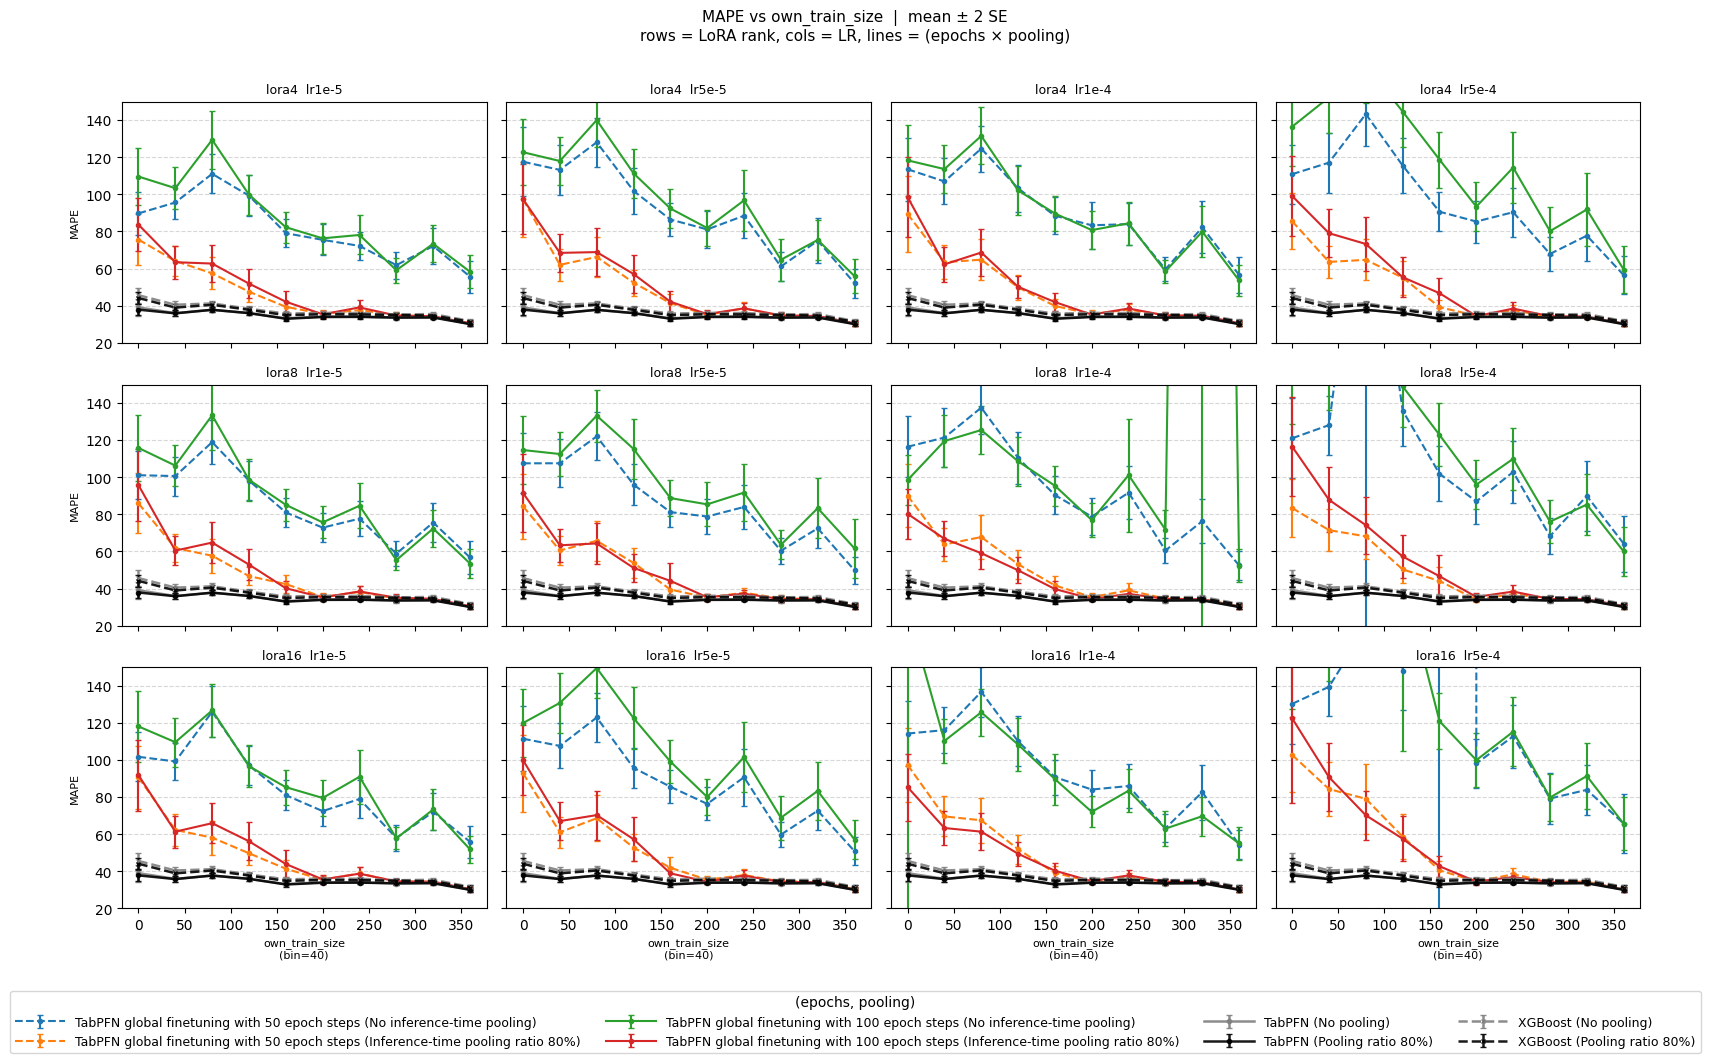

In [11]:

plot_sweep_grid(sweep_df, bucket_size=40, df2=df2, ylim=(20, 150))  # set ylim to suppress the spike

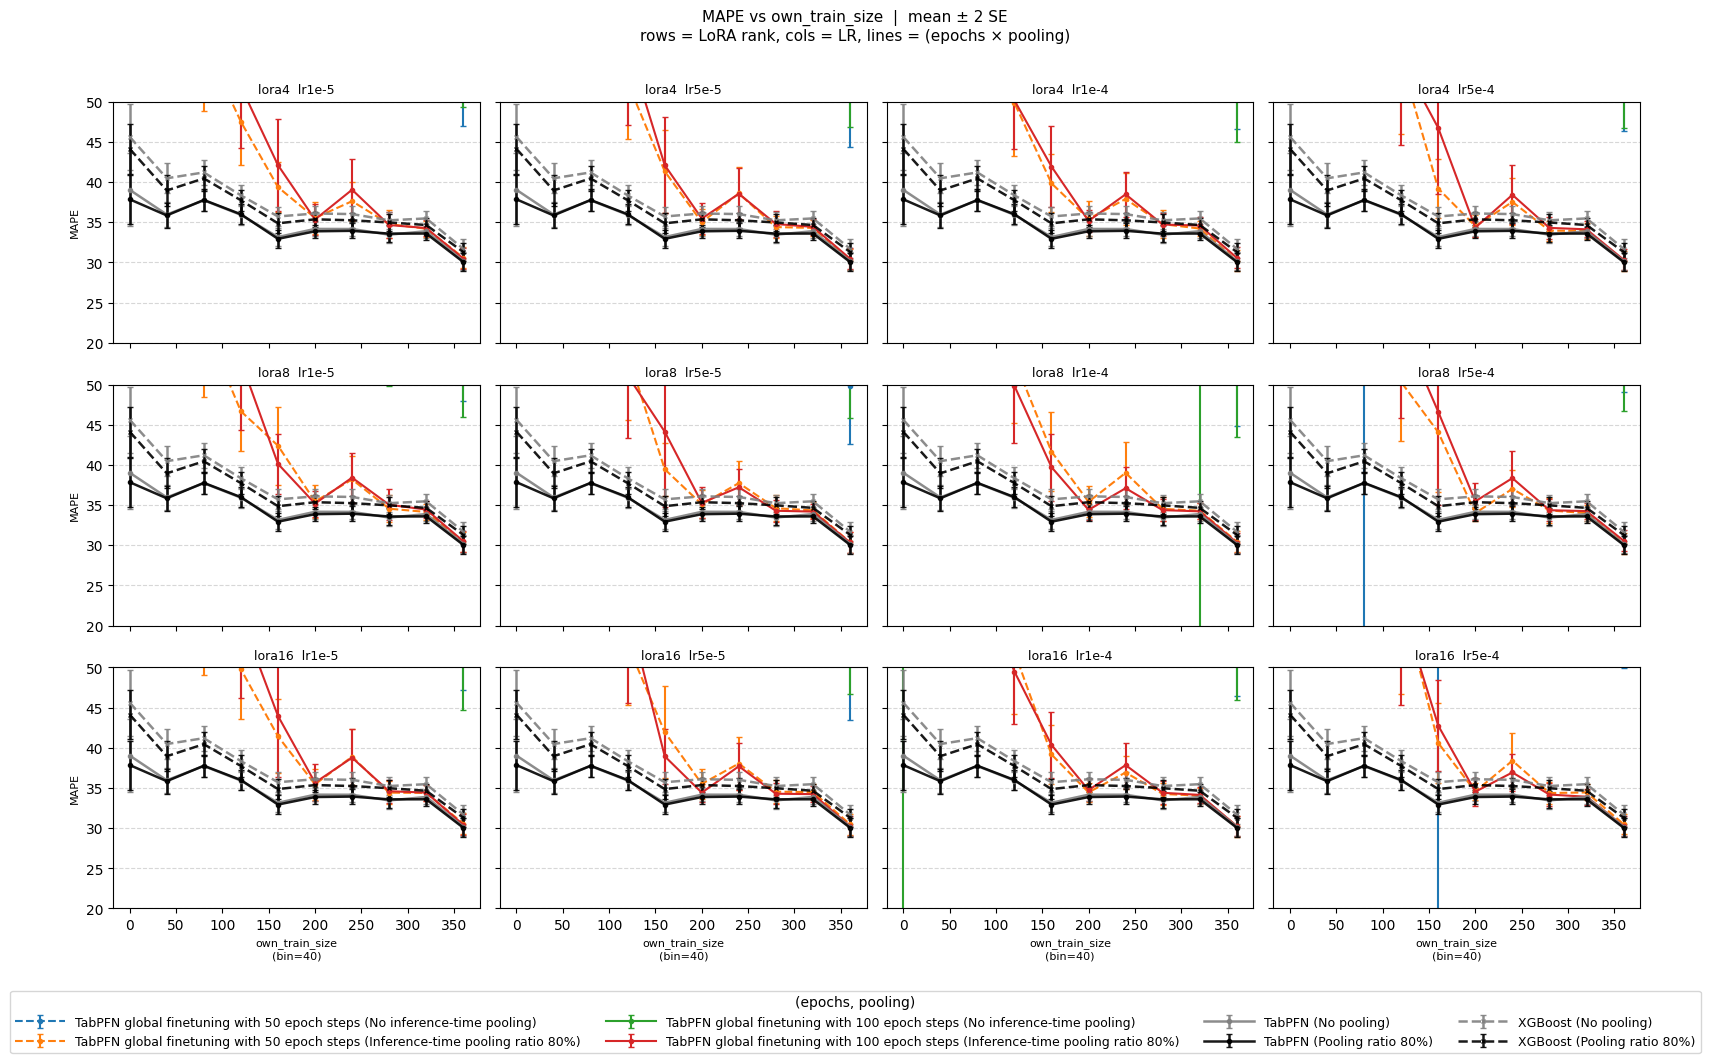

In [12]:
sweep_df = load_sweep_df()
plot_sweep_grid(sweep_df, bucket_size=40, ylim=(20, 50), df2=df2)  # set ylim to suppress the spike

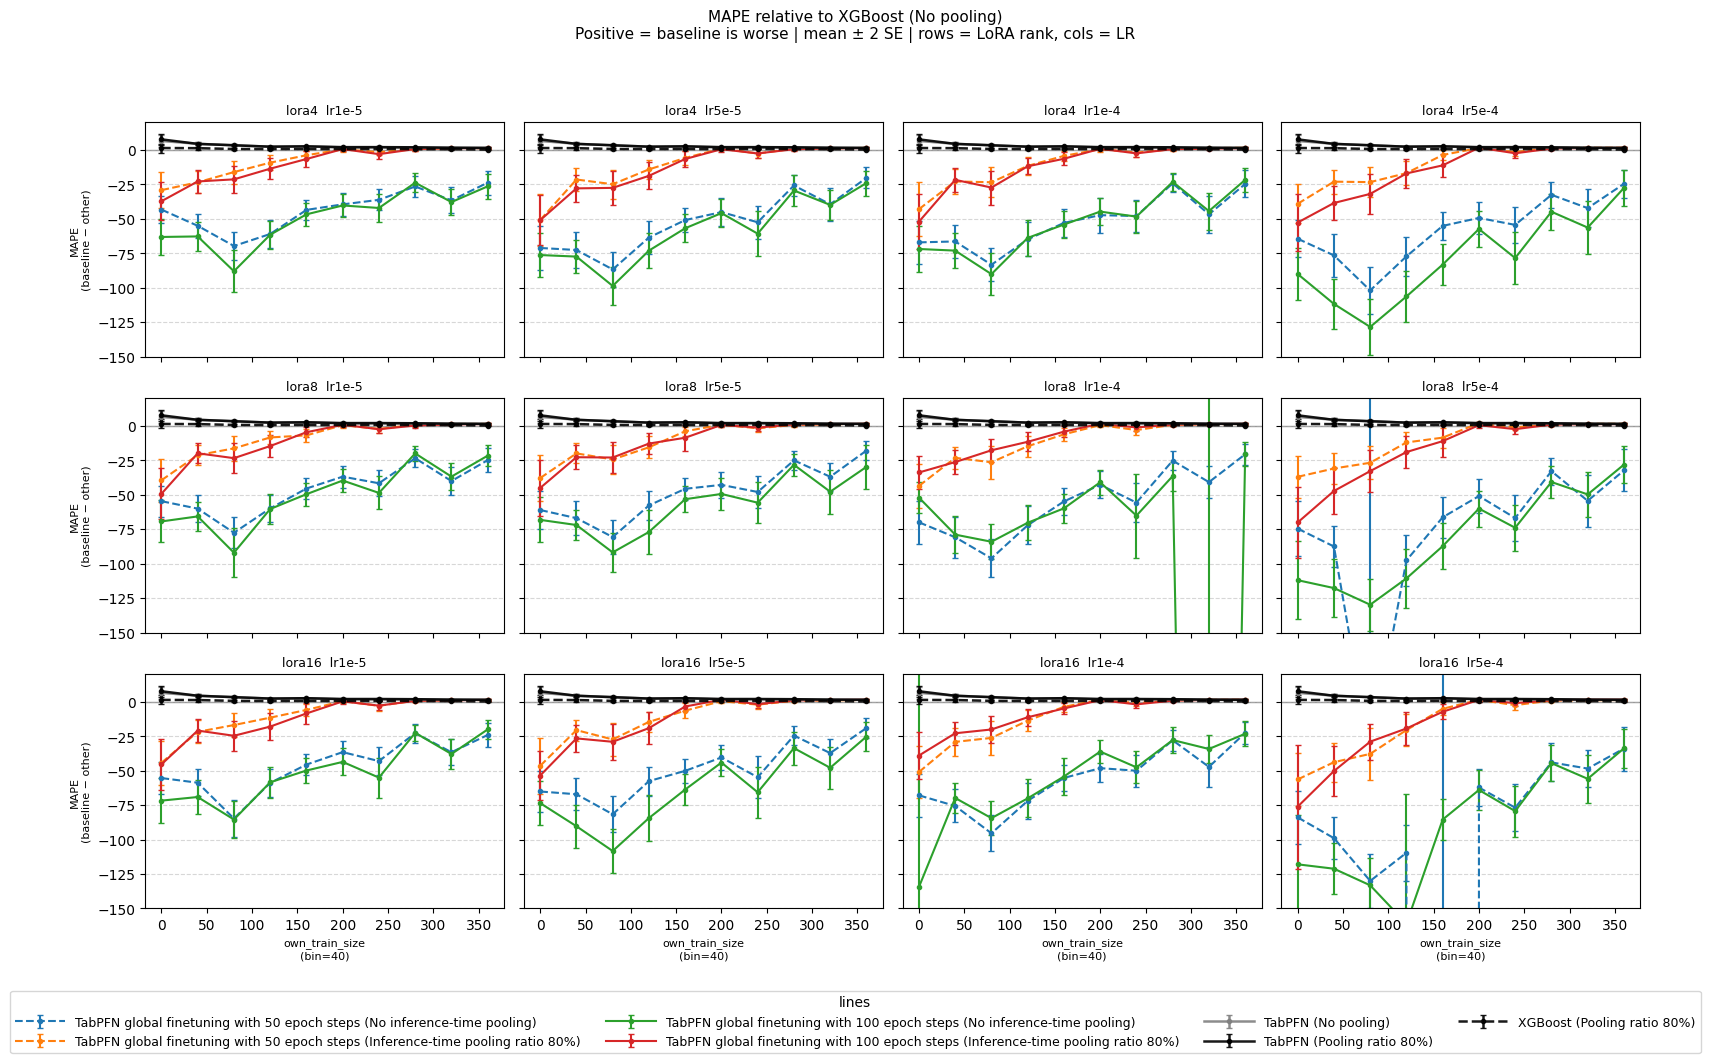

In [19]:
plot_sweep_grid_diff_from_baseline(
    df=sweep_df,
    df2=df2,
    baseline=('comparison', 'No pooling', 'xgboost'),
    metric='mape',
    bucket_size=40,
    ylim=(-150, 20)
)

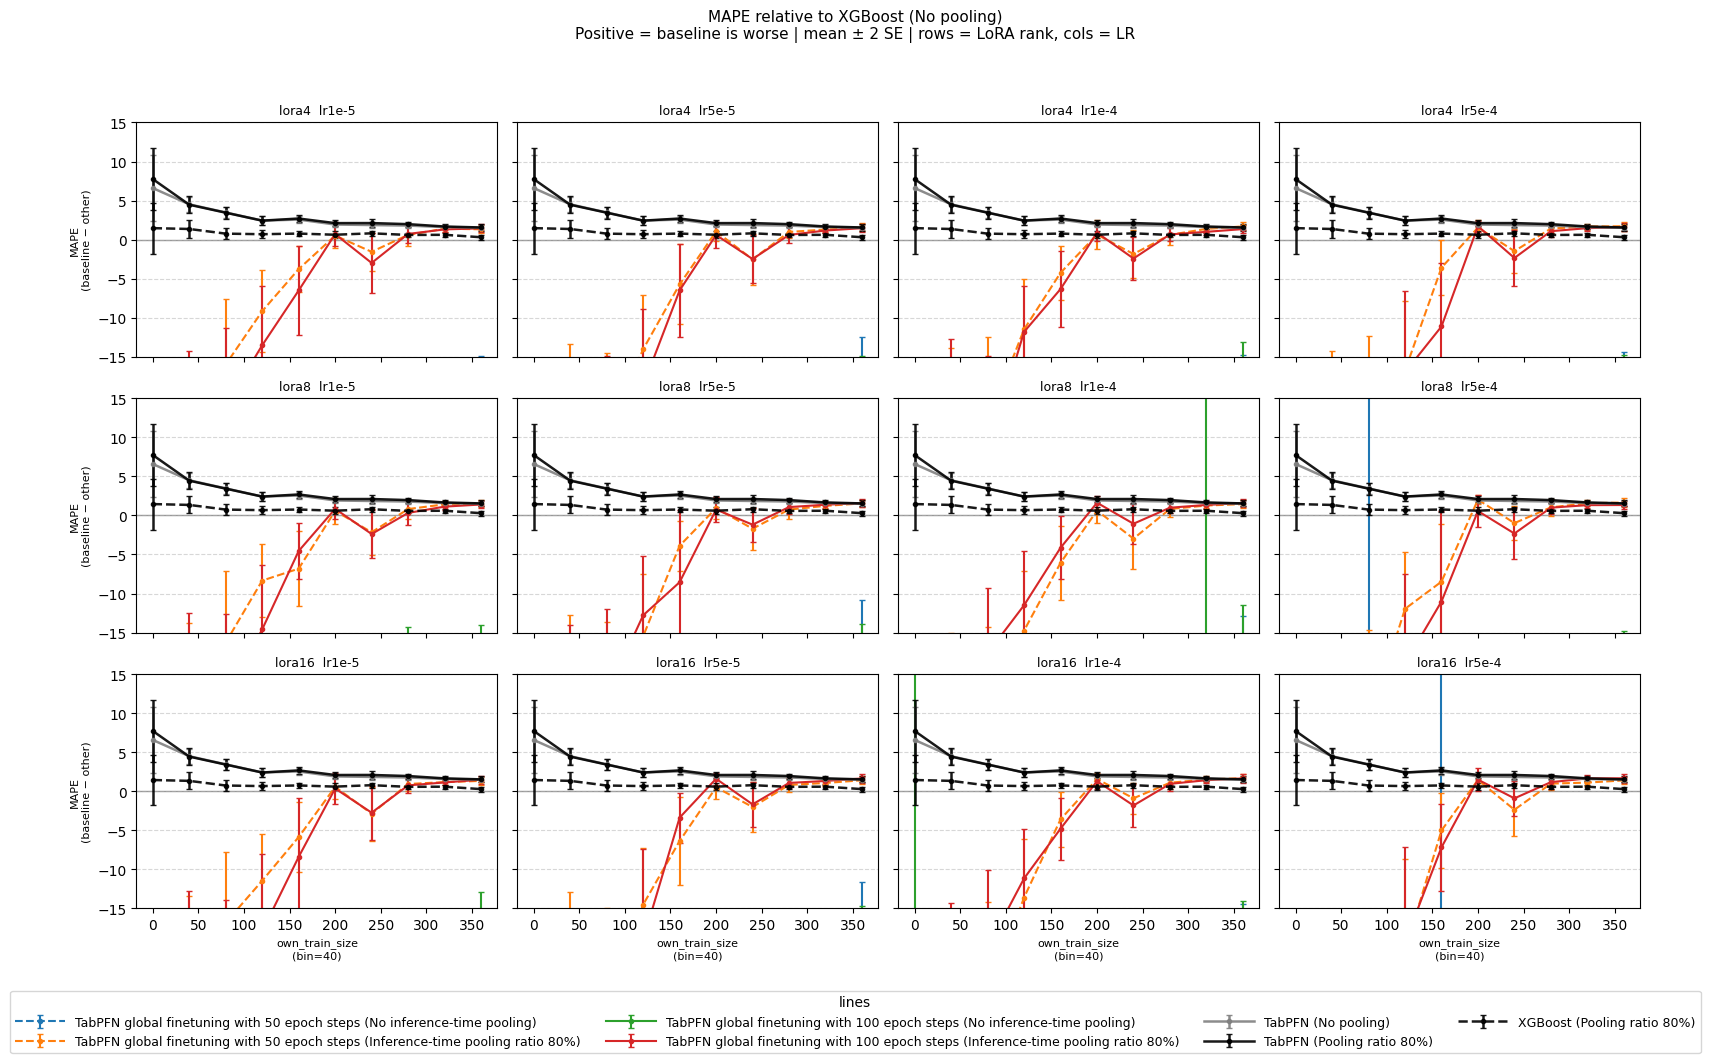

In [21]:
plot_sweep_grid_diff_from_baseline(
    df=sweep_df,
    df2=df2,
    baseline=('comparison', 'No pooling', 'xgboost'),
    metric='mape',
    bucket_size=40,
    ylim=(-15, 15)
)

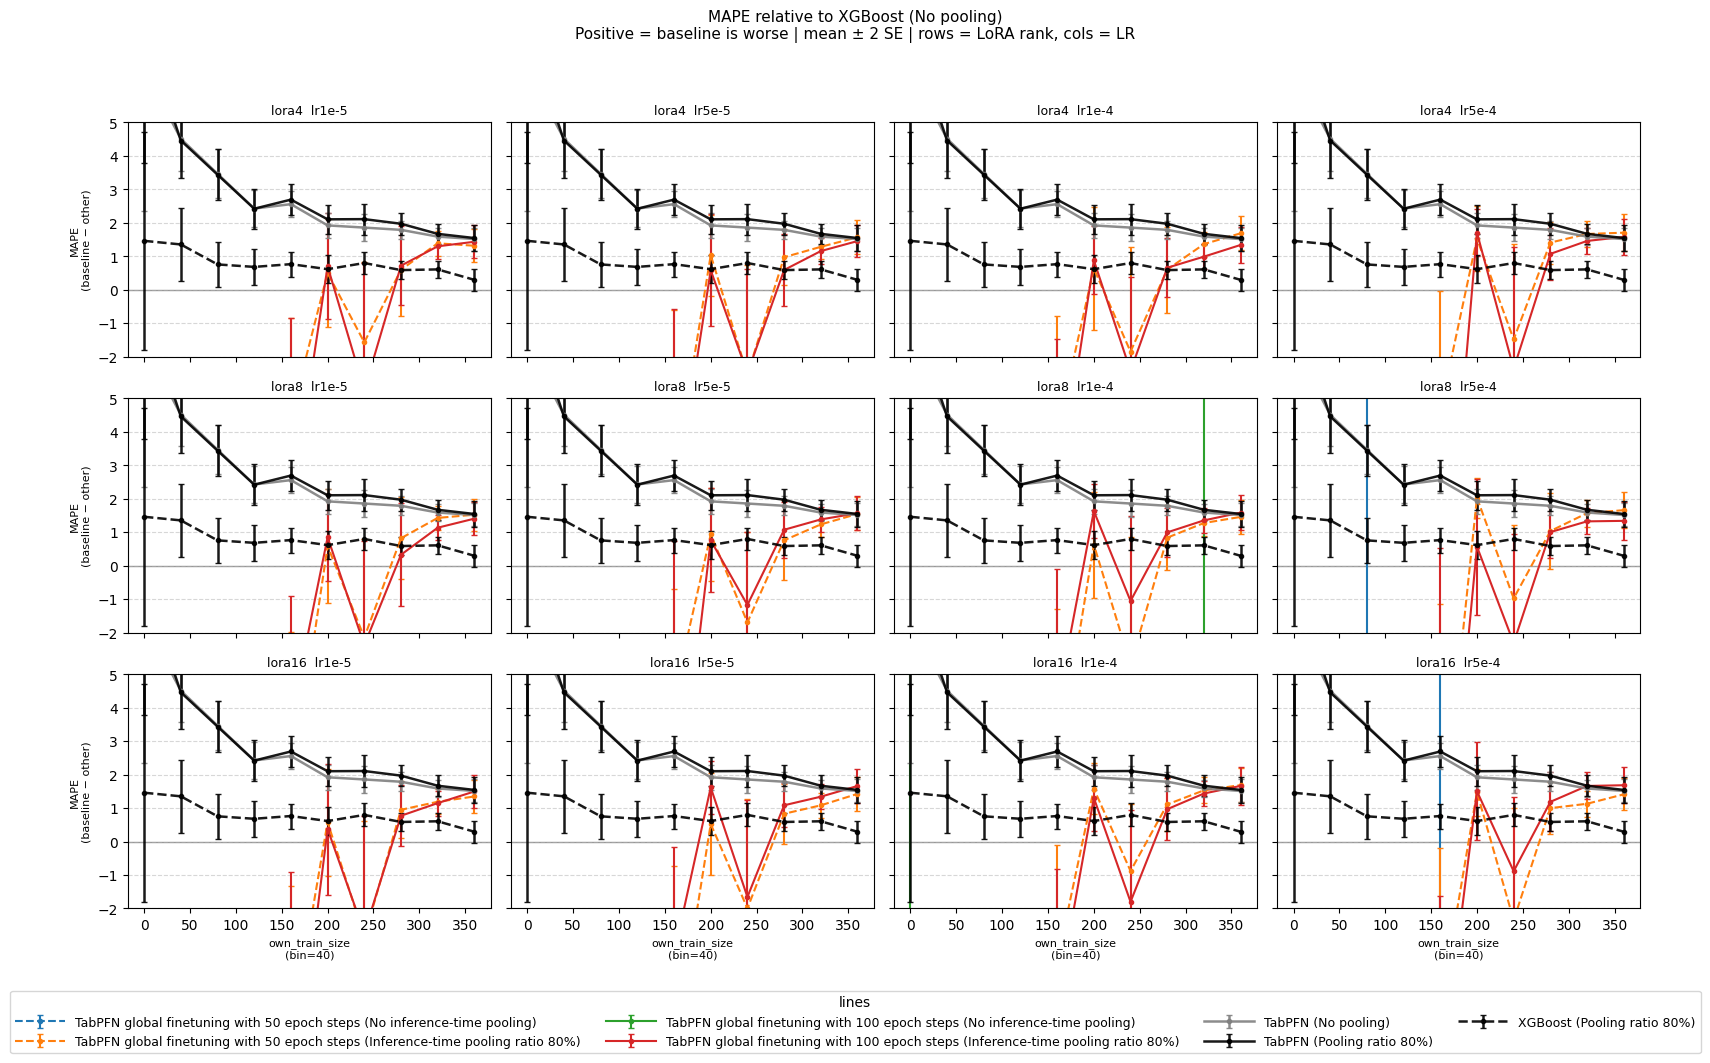

In [23]:
plot_sweep_grid_diff_from_baseline(
    df=sweep_df,
    df2=df2,
    baseline=('comparison', 'No pooling', 'xgboost'),
    metric='mape',
    bucket_size=40,
    ylim=(-2, 5)
)